In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import r3b
import ROOT
import seaborn as sns

%jsroot off

In [9]:
dir_path = "/lustre/r3b/ywang/test/s122"
mille_root_file = f"{dir_path}/test_jul21/millepede.root"
original_root_file = f"{dir_path}/test_jul8/cal2hitpar_0152.par.root"

In [10]:
original_par_reader = r3b.neuland.HitParReader(original_root_file)
original_par_reader.read()
mille_par_reader = r3b.neuland.HitParReader(mille_root_file)
mille_par_reader.read()

Number of modules: 1300
Number of modules: 1300


In [11]:
original_pars = original_par_reader.dataframe
mille_pars = mille_par_reader.dataframe

In [12]:
mille_pars

,bar_id,t_diff.error,t_diff.value,t_sync.error,t_sync.value,effective_speed.error,effective_speed.value,light_attenuation_length.error,light_attenuation_length.value,light_attenuation_factor.error,...,energy_gain.right.value,energy_gain.right.error,pmt_saturation.left.value,pmt_saturation.left.error,pmt_saturation.right.value,pmt_saturation.right.error,pmt_threshold.left.value,pmt_threshold.left.error,pmt_threshold.right.value,pmt_threshold.right.error
0,0.0,25.906810,97.715187,-640018.990505,6.530038,2.983160,15.887578,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,24.958252,94.644918,-640019.244625,6.249653,2.824619,15.194552,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,24.800728,96.471224,-640018.964426,-4.327298,2.742648,15.276405,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,35.161748,92.675065,-640019.000671,2.698304,4.143654,15.345990,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.0,123.101238,100.468217,-640019.024102,-0.219327,12.696464,14.786718,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,1295.0,7.186971,-4.877566,-693338.738720,48.202243,9.743393,16.406044,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1296,1296.0,7.829343,-5.830629,-693338.825928,52.448464,9.847372,16.713526,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1297,1297.0,6.256167,-4.034471,-693338.681569,41.757258,8.943053,16.147995,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1298,1298.0,12.652527,-5.022756,-693338.761500,47.054885,14.902323,16.616053,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
original_pars

,bar_id,t_diff.error,t_diff.value,t_sync.error,t_sync.value,effective_speed.error,effective_speed.value,light_attenuation_length.error,light_attenuation_length.value,light_attenuation_factor.error,...,energy_gain.right.value,energy_gain.right.error,pmt_saturation.left.value,pmt_saturation.left.error,pmt_saturation.right.value,pmt_saturation.right.error,pmt_threshold.left.value,pmt_threshold.left.error,pmt_threshold.right.value,pmt_threshold.right.error
0,0.0,0.063841,96.204662,1.009495,2.104638,0.122160,17.358178,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.063843,93.130120,0.755375,1.944754,0.120819,16.828252,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,0.065746,94.901450,1.035574,1.438202,0.113648,16.590405,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,0.062226,91.178368,0.999329,3.724804,0.114354,16.774491,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.0,0.061819,99.569365,0.975898,0.648343,0.109465,16.618718,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,1295.0,0.061807,-6.264035,11.261280,49.522243,0.126193,17.869244,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1296,1296.0,0.063249,-7.236092,11.174072,51.153364,0.128172,17.760326,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1297,1297.0,0.067079,-5.651524,11.318431,51.911259,0.125254,17.204495,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1298,1298.0,0.068135,-6.637104,11.238500,51.721785,0.128323,17.746953,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
def compare_par(original_pars, mille_pars, par_name):
    plot, axes = plt.subplots()
    axes.set_xticks(np.arange(0, 1301, step=100))
    axes.set_xticks(np.arange(0, 1301, step=50), minor=True)
    axes.tick_params(axis="x", labelsize=13, labelrotation=-30)
    axes.tick_params(axis="y", labelsize=13)
    axes.grid(which="both", axis="x")
    axes.grid(which="minor", alpha=0.5)
    plot.set_size_inches(13, 6)
    original_pars["label"] = "original"
    mille_pars["label"] = "millepede"
    df = pd.concat([original_pars, mille_pars], ignore_index=True)
    sns.lineplot(data=df, x="bar_id", y=par_name, ax=axes, hue="label")
    return plot, axes

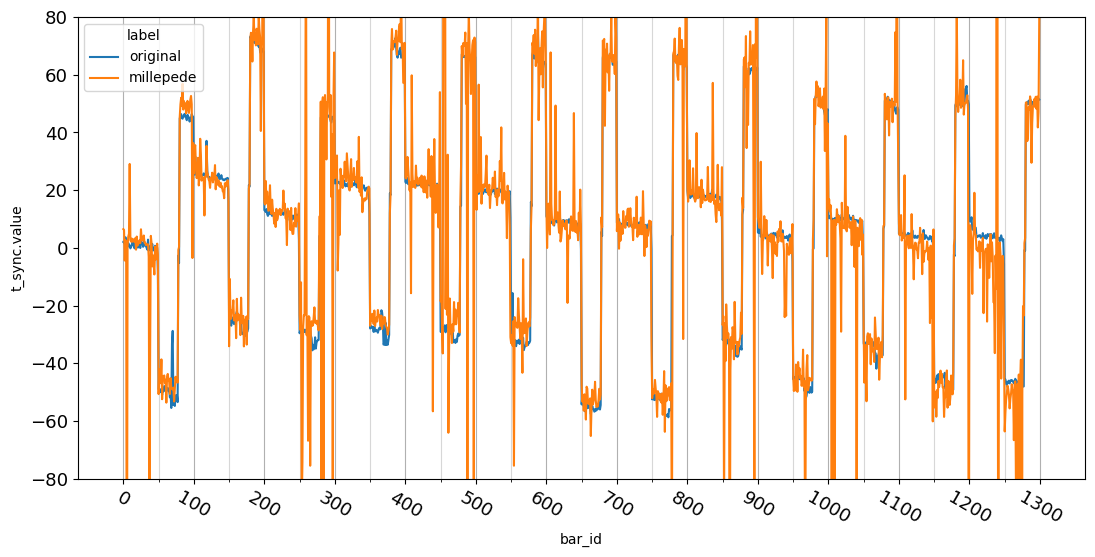

In [26]:
plot, axes = compare_par(original_pars, mille_pars, "t_sync.value")
axes.set(ylim=(-80, 80));

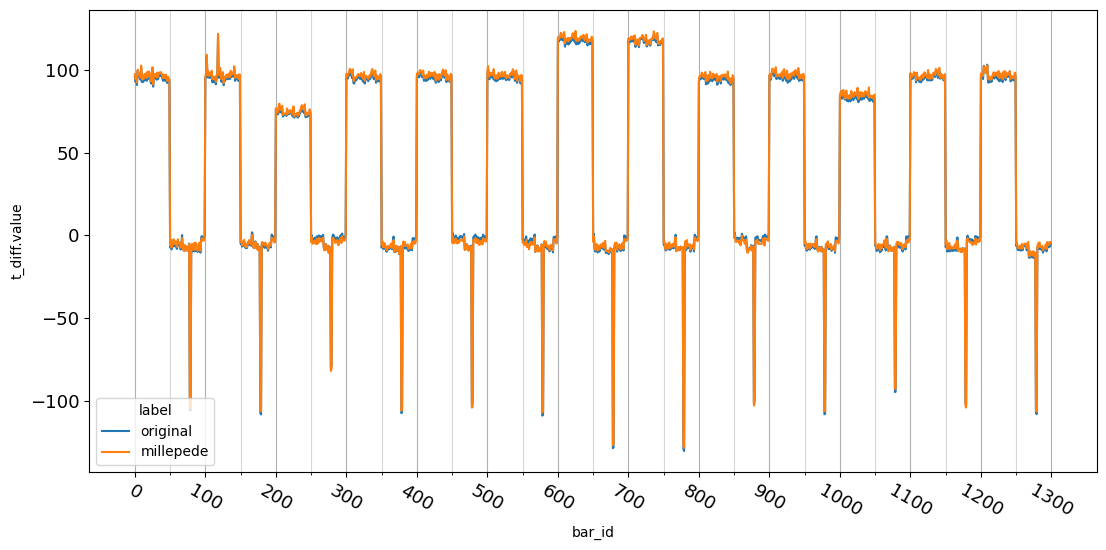

In [28]:
plot, axes = compare_par(original_pars, mille_pars, "t_diff.value")
# axes.set(ylim=(-80, 80));

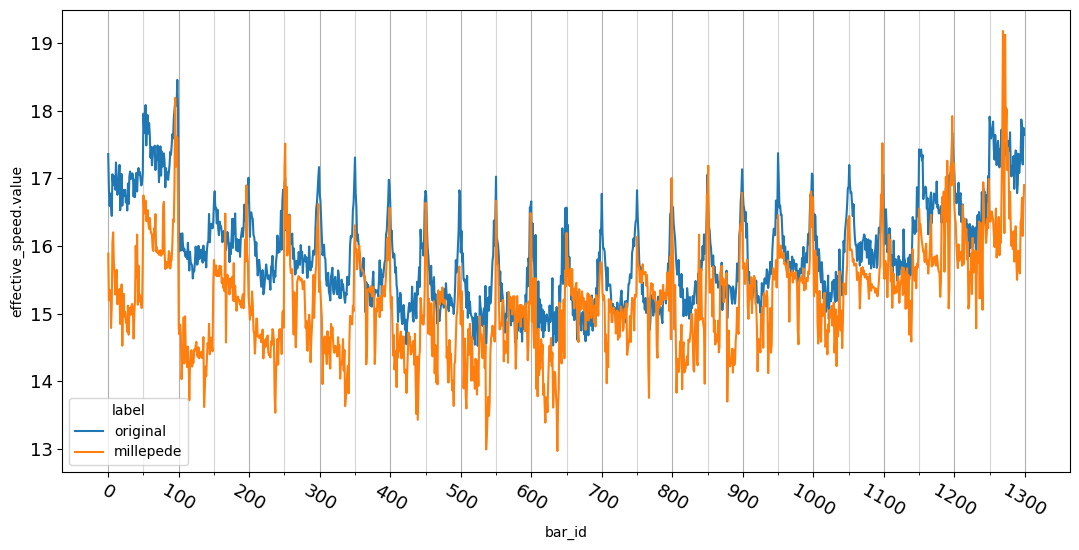

In [29]:
plot, axes = compare_par(original_pars, mille_pars, "effective_speed.value")